# Notebook 2: Market Analysis - Olist-Ecommerce-Analysis

### Name: Emmanuel Aregbesola
### Date: March, 2026
### Dataset: Cleaned data from notebook 1
### Focus: State-level marketing insights


=====================================================================================================

# 1. Introduction

**Objective**: Analyze customers' behaviours using olist ecommerce dataset on a state-level to derive insights to be used for marketing purposes and campaigns.

**Business Questions**: This notebook answers 14 different business question across 5 segments:
* Customers
* Orders
* Products
* Sellers
* DElivery

**Data Sources**: Our datasets are gotten from the cleaned data in the previous notebook **01 - Olist dataset cleaning**:

* cleaned_customers.csv 
* cleaned_geolocation.csv
* cleaned_order_items.csv
* cleaned_orders.csv
* cleaned_payment.csv
* cleaned_product_category.csv
* cleaned_products.csv
* cleaned_reviews.csv
* cleaned_sellers.csv


=====================================================================================================

# 2. Data Loading and Preparation

**Objective**: To load all datasets and prepare for state-level analysis.

**Steps:**
1. Import all necessary libraries(pandas, matplotlib, seaborn etc.)
2. Load all 9 cleaned datasets
3. verify data types of all datasets
4. Create a database
5. Create corresponding tables for sql database

In [1]:
# Import all necassary libraries

import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load all the cleaned datasets

files = {
    'customers' : 'cleaned_customers.csv',
    'geolocation' : 'cleaned_geolocation.csv',
    'order_items' : 'cleaned_order_items.csv',
    'orders' : 'cleaned_orders.csv',
    'payments': 'cleaned_payment.csv',
    'product_category' : 'cleaned_product_category.csv',
    'products' : 'cleaned_products.csv',
    'reviews' : 'cleaned_reviews.csv',
    'sellers' : 'cleaned_sellers.csv'
}

data = {}

for name, file in files.items():
    data[name] = pd.read_csv(file)
    
print(f'All files are loaded into pandas!')

All files are loaded into pandas!


In [3]:
# verify the data types using info() 

for name, df in data.items():
    print(f'{name.upper()}')
    print(f'{df.info()} \n')

CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None 

GEOLOCATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 738332 entries, 0 to 738331
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  int64  
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
 3   geolocation_city         

In [4]:
# convert all date columns across all dataframe to datetime

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for df in data.values():
    for col in date_columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])

In [5]:
# validate the change to datetime

for name, df in data.items():
    print(f'{name.upper()}')
    print(f'{df.info()} \n')

CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None 

GEOLOCATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 738332 entries, 0 to 738331
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  int64  
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
 3   geolocation_city         

In [6]:
# Create a shortcut for a dataframe

customers_df = data['customers']
geo_df = data['geolocation']
order_items_df = data['order_items']
products_df = data['products']
reviews_df = data['reviews']
orders_df = data['orders']
payments_df = data['payments']
product_category_df = data['product_category']
sellers_df = data['sellers']

In [7]:
# create a database
# database credentials removed for security
# replace USERNAME and PASSWORD with your local credentials

engine = create_engine(
    "postgresql://<username>:<password>@localhost:5432/olist_database"
)

In [40]:
# create tables for sql execution
# Had to comment out this cell 
# Running this cell twice will result to an error.
# Un-comment if you want to run this cell yourself

#customers_df.to_sql('customers', engine, if_exists='replace', index=False)
#geo_df.to_sql('geolocation', engine, if_exists='replace', index=False)
#order_items_df.to_sql('order_items', engine, if_exists='replace', index=False)
#products_df.to_sql('products', engine, if_exists='replace', index=False)
#reviews_df.to_sql('reviews', engine, if_exists='replace', index=False)
#orders_df.to_sql('orders', engine, if_exists='replace', index=False)
#payments_df.to_sql('payments', engine, if_exists='replace', index=False)
#product_category_df.to_sql('product_category', engine, if_exists='replace', index=False)
#sellers_df.to_sql('sellers', engine, if_exists='replace', index=False)

# print(f'Sql tables created!')

# 3. Customer Analysis - Who buys from us?

**Objectives**: Identify high-value customer states for targeted acquistion

### Question 1: Which state has the most customers?
### Question 2: Which state has the highest average customer spend?
### Question 3: In the last 3 months, which state had the highest spend?

=====================================================================================================

**Step**: To answer these questions above, this code was ran in postgresql environment:
**CREATE VIEW customer_master AS
SELECT
    c.customer_id,
    c.customer_state,
    o.order_id,
    o.order_purchase_timestamp,
    oi.order_item_id,
    oi.price,
    pa.payment_value
FROM customers c
JOIN orders o
    ON o.customer_id = c.customer_id
JOIN order_items oi
    ON oi.order_id = o.order_id
JOIN payments pa
    ON pa.order_id = o.order_id;**
    
Now, we can head to answering the questions below

## Question 1: Which state has the most customers?

**Top State**: Sao Paulo (SP) with **41,374** customers.


| State | Customer_count|
|-------|---------------|
|	SP	| 41374         |
|	RJ	| 12762         |
|	MG	| 11544         |
|	RS	| 5432          |
|	PR	| 4998          |

**Insights:**
**Sao Paulo** alone accounts for **46.365** of the top 10 states with the highest customers. The top three states (SP, RJ, MG) cummulatively accounts for over 70% of the customer base. The marketing team should make these state their top priority especially **Sao Paulo**.

**Action:**
Focus should be on the three states which have over 70% of the total customer base in the top 10 states. Also, targeted ads should be done to the mid-tiers state to increase customer base there.


In [9]:
# calculate the data

quest1 = pd.read_sql('''
SELECT 
customer_state,
COUNT(DISTINCT customer_id) AS cust_count
FROM customer_master
GROUP BY customer_state
ORDER BY cust_count DESC
LIMIT 10;
''', engine)

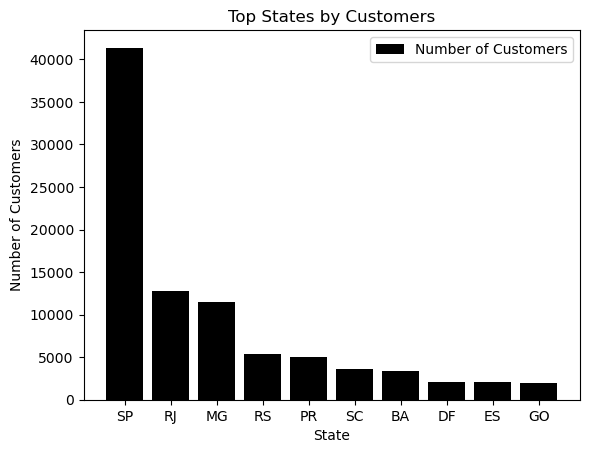

In [10]:
# Visualize the data

x1 = quest1['customer_state']
y1 = quest1['cust_count']

plt.bar(x1, y1, color='black', label='Number of Customers')

plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.title('Top States by Customers')
plt.legend(loc='upper right')

plt.show()

## Question 2: Which state has the highest average Customer spend?

**Top State:** Paraíba (PB) with an average order value of **RS340.20**.

| customer_state | avg_value |
|----------------|-----------|
|	PB	         |  340.20   |
|   AP	         |  318.28   |
|	AC	         |  308.46   |
|   MT           |	284.39   |
|	PI	         |  277.44   |


**Insights:**
Although Sao Paulo accounts for the highest customer count amongst all the customers, it doesn't account for highest average money spent by customers. Sao Paulo has the lowest average revenue in all the states with **RS183.62** as its average value.
This is because of its sheer volume in customer base. 


In [11]:
# aggregate the data

quest2 = pd.read_sql('''
SELECT 
c.customer_state AS customer_state,
AVG(sum) as avg_value
FROM
    (SELECT
    customer_id,
    customer_state,
    SUM(payment_value) as sum
    FROM customer_master
    GROUP BY customer_id, customer_state) c
GROUP BY c.customer_state
ORDER BY avg_value DESC
LIMIT 10;
''', engine
)

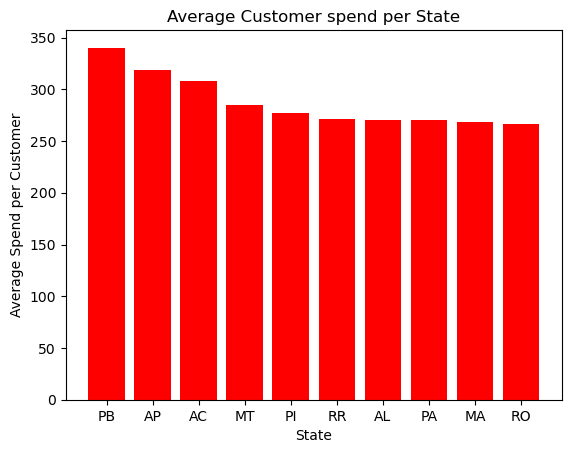

In [12]:
# visualize the data

x1 = quest2['customer_state']
y1 = quest2['avg_value']

plt.bar(x1, y1, color='red')
plt.xlabel('State')
plt.ylabel('Average Spend per Customer')
plt.title('Average Customer spend per State')


plt.show()

## Question 3: In the last 3 months, which state had the highest spend?

**Top State**: **Sao Paulo**

**Insight**: Sao Paulo is the state with the highest spend in the last three month. Sao Paulo spends 3.6x more than the next state on the list. This is understandable since they account for 46% of the top 10 states.

In [13]:
# Aggregate the data

quest3 = pd.read_sql('''
SELECT 
customer_state,
SUM(payment_value) AS revenue
FROM customer_master
WHERE order_purchase_timestamp >= 
      (SELECT 
       date_trunc('month', MAX(order_purchase_timestamp)) - INTERVAL '2 months'
       FROM customer_master)
GROUP BY customer_state
ORDER BY revenue DESC
LIMIT 10;
''', engine)

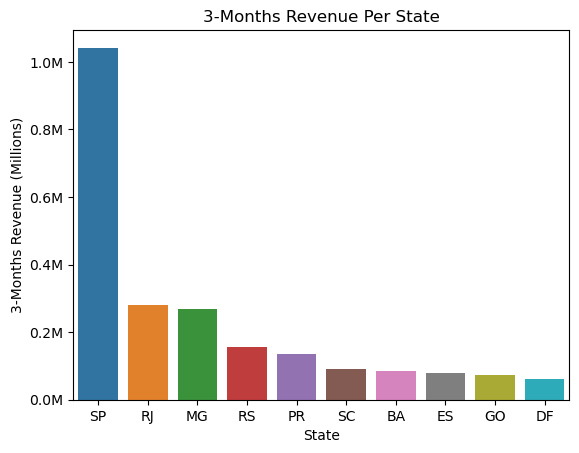

In [14]:
# visualize the data

import matplotlib.ticker as ticker

ax = sns.barplot(data=quest3, x='customer_state', y='revenue')

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.xlabel('State')
plt.ylabel('3-Months Revenue (Millions)')
plt.title('3-Months Revenue Per State')

plt.show()

# 4. ORDER BEHAVIOR - HOW DO CUSTOMERS BUY?

**Objective**: Understand purchase patterns to optimize campaign timing and messaging.
    
### Question 4: What is the average order value by state?
### Question 5: Do high-priced products sell in lower quantities?
### Question 6: Which month across years has the highest revenue by state?

==============================================================================================

## Question 4: What is the average order value per state?

**Insight**: The average value lies in the **RS200** Range.

**Action**: Discount can be offered to customers when they buy poducts worth of R$200 or more


In [15]:
# aggregate the data

quest4 = pd.read_sql('''
SELECT
customer_state,
AVG(payment_value) AS avg_revenue
FROM customer_master
GROUP BY customer_state
ORDER BY avg_revenue DESC
LIMIT 10;
''', engine)

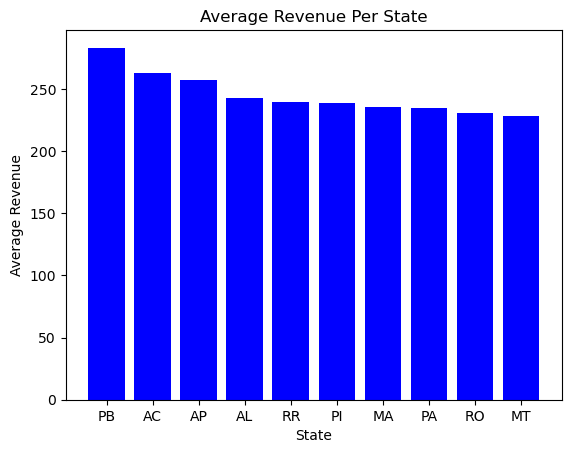

In [16]:
# visualize the data

x4 = quest4['customer_state']
y4 = quest4['avg_revenue']

plt.bar(x4, y4, color='blue')
plt.xlabel('State')
plt.ylabel('Average Revenue')
plt.title('Average Revenue Per State')

plt.show()

## Question 5: Do high-priced products sell in lower quantities?

**Insights**: 
* From the scatter plot, the lower the price, the higher the quantity and vice versa. 
* Most of the purchases happen around R$10 - R$200
* There is an interesting peak around the R$100

In [17]:
# aggregate the data

quest5 = pd.read_sql('''
SELECT
product_id,
AVG(price) AS avg_price,
COUNT(order_item_id) AS quantity
FROM order_items
GROUP BY product_id;
''', engine)

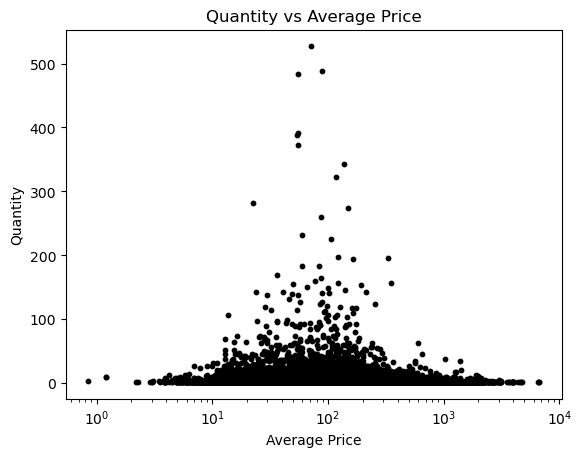

In [18]:
# visualize the data

x5 = quest5['avg_price']
y5 = quest5['quantity']

plt.scatter(x5, y5, color='black', s=10)
plt.ylabel('Quantity')
plt.xlabel('Average Price')
plt.title('Quantity vs Average Price')
plt.xscale('log')

plt.show()

## Question 6: Which month across years has the highest revenue by state?

**Insights**: Using the graph, we can see the highest month and year that brought the most revenue for each state. Although we can see this data, there is a limitation.

**Limitation**: This graph just shows us the month in which the states had their highest revenue, we do not know if this is a recurring observation or a one-off.



In [19]:
# aggregate the data

quest6 = pd.read_sql('''
SELECT
c.customer_state,
c.month,
c.total_revenue
FROM
	(SELECT
	customer_state,
	DATE_TRUNC('month', order_purchase_timestamp) AS month,
	SUM(payment_value) AS total_revenue,
	ROW_NUMBER() OVER(
		PARTITION BY customer_state 
		ORDER BY SUM(payment_value) DESC
	) AS rnk
	FROM customer_master
	GROUP BY customer_state, month) c
WHERE c.rnk = 1;
''', engine)

In [20]:
quest6['month_year'] = quest6['month'].dt.strftime('%B, %Y')

In [21]:
quest6

,customer_state,month,total_revenue,month_year
0,AC,2018-07-01,5002.15,"July, 2018"
1,AL,2017-11-01,12699.29,"November, 2017"
2,AM,2018-02-01,5128.02,"February, 2018"
3,AP,2018-01-01,4433.32,"January, 2018"
4,BA,2018-02-01,70708.70,"February, 2018"
5,CE,2018-03-01,32757.28,"March, 2018"
6,DF,2017-11-01,41648.62,"November, 2017"
7,ES,2018-07-01,58276.40,"July, 2018"
8,GO,2017-08-01,64008.46,"August, 2017"
9,MA,2018-05-01,24965.21,"May, 2018"


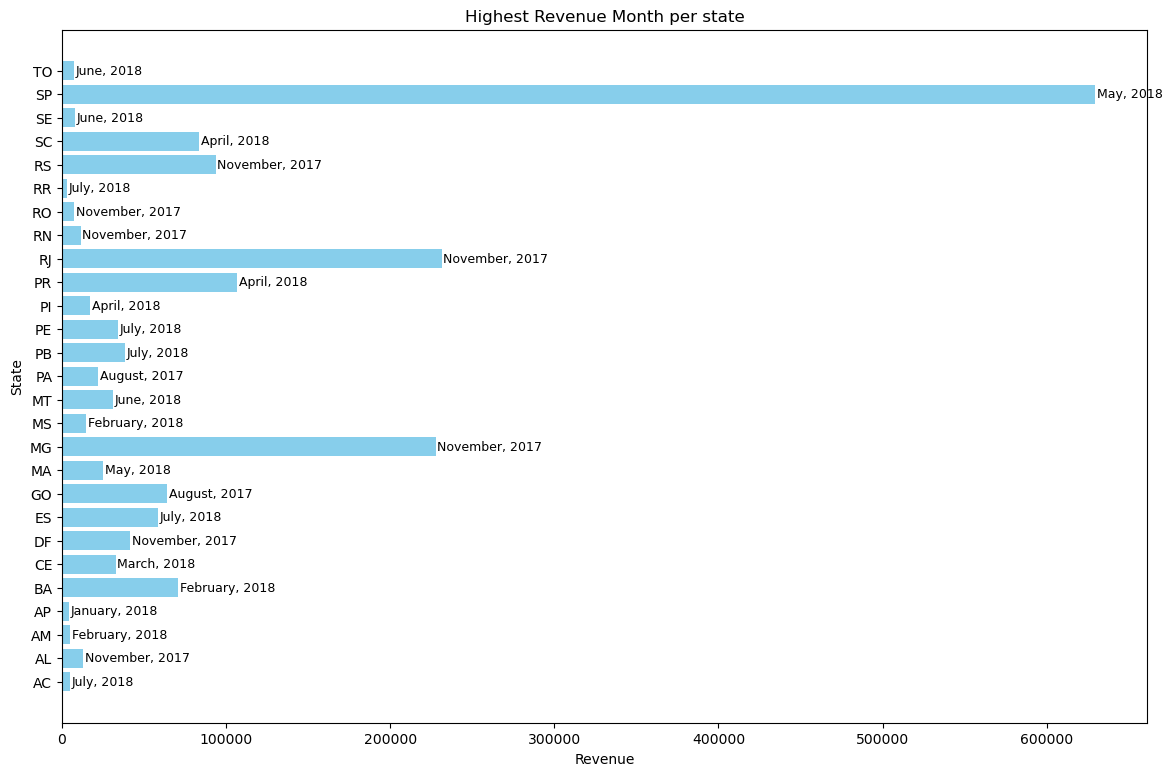

In [22]:
# visualize the data

x6 = quest6['customer_state']
y6 = quest6['total_revenue']
month_year = quest6['month_year']

plt.figure(figsize=(14,9))
bars = plt.barh(x6, y6, color='skyblue')
plt.xlabel('Revenue')
plt.ylabel('State')
plt.title('Highest Revenue Month per state')

for bar, month in zip(bars, month_year):
    plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             month, va='center', fontsize=9)

plt.show()

# 5. PRODUCT ANALYSIS - WHAT SELLS WHERE?
 
**Objective:** Tailor product promotions to regional preferences.

### Question 7: Top 10 Highest-Revenue Products Across All States?
### Question 8: Top 10 category by total revenue?

===============================================================================================

The sql code used in creating a view to answer these questions:

**CREATE VIEW product_master AS
SELECT 
	cm.customer_state,
	cm.payment_value,
	oi.product_id,
	p.product_category_name
FROM customer_master cm
JOIN order_items oi
ON oi.order_id = cm.order_id
JOIN products p
ON p.product_id = oi.product_id;**

# Question 7: Top 10 Highest-Revenue Products Across All States?

**Top Product**: 9571759451b1d780ee7c15012ea109d4

**Insights:** We can see from the graph that we have three major products that sells alot across all states and categories. The 3rd product sells 3x more than the 4th product.

In [23]:
# aggregate the data

quest7 = pd.read_sql('''
SELECT
c.customer_state,
c.product_id,
c.product_category_name,
c.total_revenue
FROM
	(SELECT
	customer_state,
	product_id,
	product_category_name,
	SUM(payment_value) AS total_revenue,
	DENSE_RANK() OVER(
		PARTITION BY customer_state
		ORDER BY SUM(payment_value) DESC
	) AS rnk
	FROM product_master
	GROUP BY customer_state, product_id, product_category_name) c
WHERE c.rnk <= 1
ORDER BY c.total_revenue DESC
LIMIT 10;
''', engine)

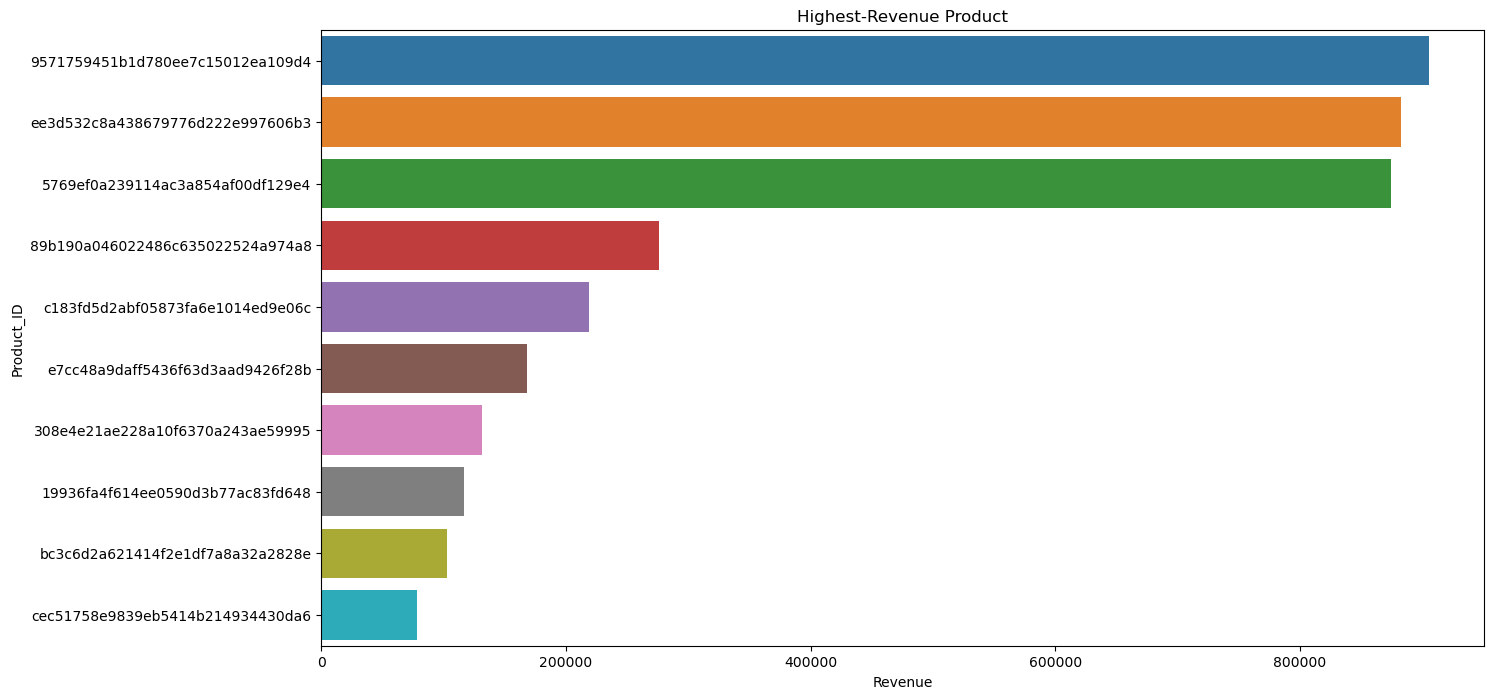

In [24]:
# visualize the data

plt.figure(figsize=(15,8))

sns.barplot(data=quest7,
           y='product_id',
           x='total_revenue')

plt.xlabel('Revenue')
plt.ylabel('Product_ID')
plt.title('Highest-Revenue Product')

plt.show()

# Question 8: Top 10 category by total revenue?

**Top product Category**: Computer Accessories


In [25]:
# aggregate the data

quest8 = pd.read_sql('''
SELECT 
product_category_name,
SUM(payment_value) AS Revenue
FROM product_master
GROUP BY product_category_name
ORDER BY Revenue DESC
LIMIT 10;
''', engine)

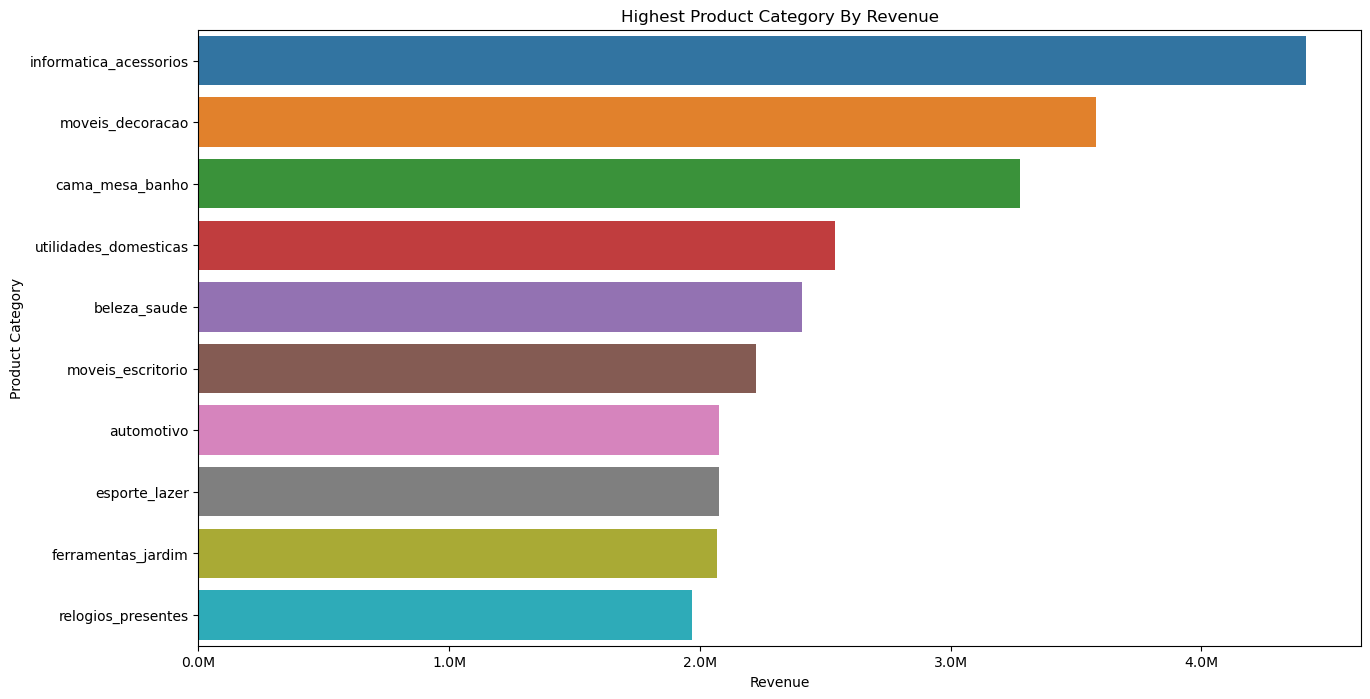

In [26]:
# visualize the data

plt.figure(figsize=(15,8))

bx = sns.barplot(data=quest8, x='revenue', y='product_category_name')
bx.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.title('Highest Product Category By Revenue')
plt.show()

# 6. SELLER ANALYSIS - WHO SELLS TO OUR CUSTOMERS?

**Marketing Goal**: Identify high-quality sellers to feature in campaigns.

### Qustion 9: Top 10 sellers by sales volume?
### Question 10: Top 5 sellers by average reviews?
### Question 11: Poor customers by reliability?

=================================================================================

# Qustion 9: Top 10 sellers by sales volume?


**Top Seller:** 7c67e1448b00f6e969d365cea6b010ab

**Insights:** The top seller, 7c67e1448b00f6e969d365cea6b010ab, is 1.6x higher in sales volume than the second highest.

In [27]:
# aggregate the data

quest9 = pd.read_sql('''
SELECT
oi.seller_id,
SUM(o.payment_value) AS volume
FROM order_items oi
JOIN payments o
ON oi.order_id = o.order_id
GROUP BY oi.seller_id
ORDER BY volume DESC
LIMIT 10;
''', engine)

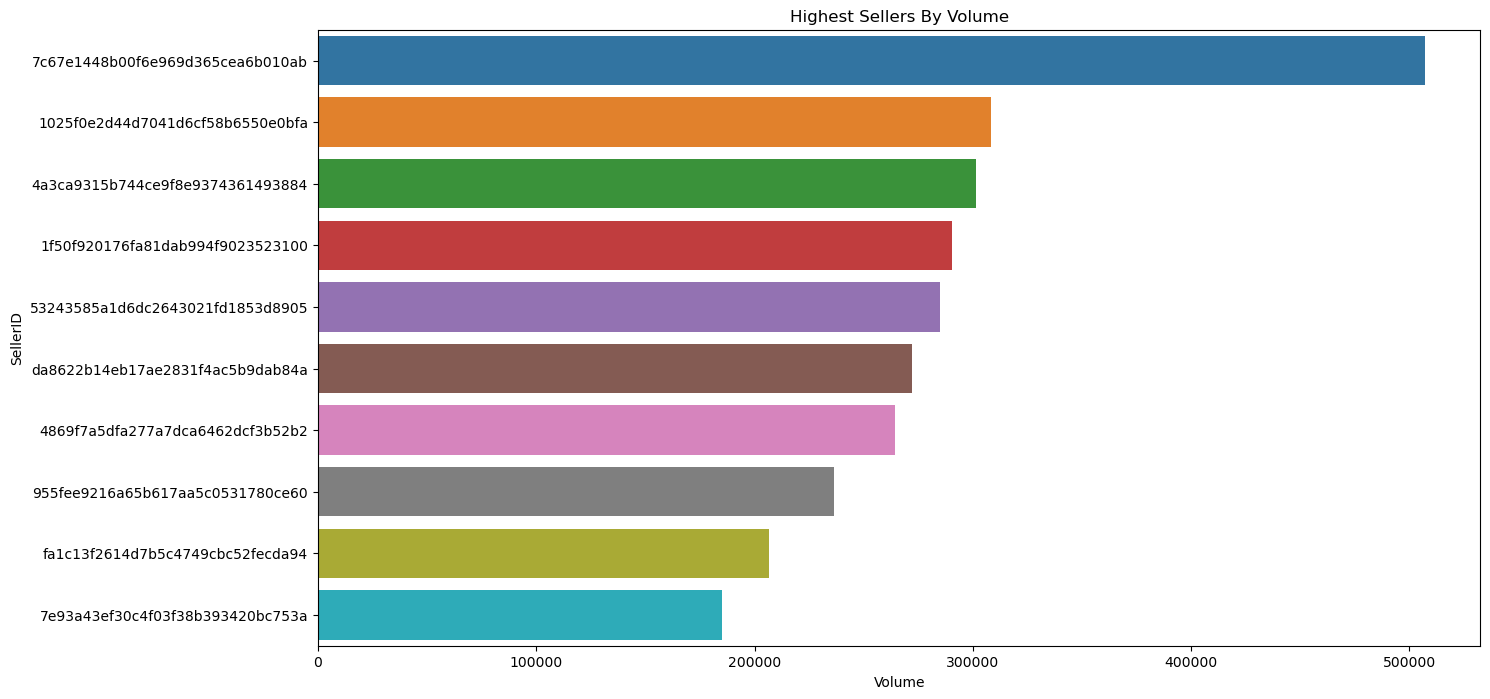

In [28]:
# visualize the data

plt.figure(figsize=(15,8))

sns.barplot(data=quest9, x='volume', y='seller_id')

plt.xlabel('Volume')
plt.ylabel('SellerID')
plt.title('Highest Sellers By Volume')

plt.show()

# Question 10: Top 5 sellers by average reviews?

**Insights:** There are a lot of sellers with perfect average score, and this is because we did not take into consideration of sellers with a lot of orders. A seller who has only sold one product would also be on the list.
What will be done is, filtering the sellers with a fixed amount of orders to get a reliable insight into the average review score.

In [29]:
# aggregate the data

quest10 = pd.read_sql('''
SELECT
oi.seller_id,
AVG(r.review_score) AS average_score
FROM reviews r
JOIN order_items oi
ON oi.order_id = r.order_id
GROUP BY oi.seller_id
ORDER BY average_score DESC
LIMIT 5;
''', engine)

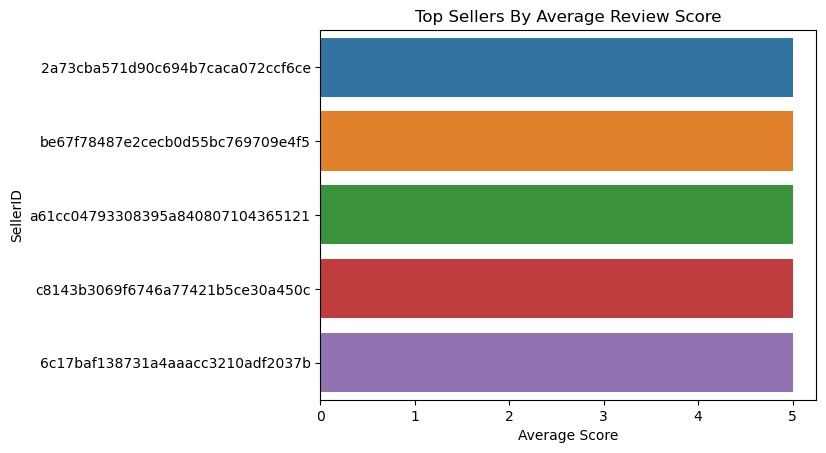

In [30]:
# visualize the data

sns.barplot(data=quest10, x='average_score', y='seller_id')

plt.xlabel('Average Score')
plt.ylabel('SellerID')
plt.title('Top Sellers By Average Review Score')
plt.show()

# Question 11: Poor customers by reliability

**Insights:** There are not more than one failure rate, which is a good one. We can say on an average customers experience failure in their delivery only once in their time on the platform. A better metric would have been on the seller side, if particular sellers have more than average order failure rates.

In [31]:
# aggregate the data

quest11 = pd.read_sql('''
SELECT
customer_unique_id,
COUNT(*) AS total_orders,
SUM(
    CASE
        WHEN order_status IN ('unavailable','cancelled')
        THEN 1 ELSE 0
    END
) AS failure_count,
SUM(
    CASE
        WHEN order_status IN ('unavailable','cancelled')
        THEN 1 ELSE 0
    END
) * 1.0 / COUNT(*) AS failure_rate
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
GROUP BY customer_unique_id
ORDER BY failure_rate DESC
LIMIT 10;
''', engine)

In [32]:
quest11

,customer_unique_id,total_orders,failure_count,failure_rate
0,02d73d09e28bcf111eb693e80e33cb51,1,1,1.0
1,034e7f551239546ae63e45d0b1186ab1,1,1,1.0
2,013b083525868a0437652ebf071cda03,1,1,1.0
3,027b5658f8a94a67c3d037047ca849c5,1,1,1.0
4,02ed27f9cd8f0a7ffc59c7e10b46b9c0,1,1,1.0
5,03459d9b3e14feb0e89b0e5bce4f188d,1,1,1.0
6,004ad212c650c96c8a48f30855a7bcb8,1,1,1.0
7,0071f46a072a9ae25bbe4438b15efe9c,1,1,1.0
8,020d46eecb7bda2b3ab2316a91bb49f6,1,1,1.0
9,035b968ba397e88fb108e40bc65de2b4,1,1,1.0


# 7. DELIVERY ANALYSIS - HOW FAST DO CUSTOMERS GET THEIR ORDERS?

### Question 12: What is the average timeline from purchase to delivered?
### Question 13: Accuracy (Estimated vs. Actual)?
### Quetion 14: Average cost per delivery?

==============================================================================

# Question 12: What is the average timeline from purchase to delivered?

**Insights:** **Sao Paulo** has the shortest delivery timeline window out of all the other states. The days between Sao Paulo and the next day is 3 days. This brings me to the conclusion that because of the high volume of customers in Sao Paulo, the numbers was in their favor.

In [33]:
# aggregate the data

quest13 = pd.read_sql('''
SELECT 
c.customer_state,
AVG((o.order_delivered_customer_date) -
(o.order_purchase_timestamp)) AS avg_delivery_period
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
WHERE order_status = 'delivered'
GROUP BY customer_state
ORDER BY avg_delivery_period;
''', engine)

In [34]:
quest13['timeline'] = quest13['avg_delivery_period'].dt.days

quest13

,customer_state,avg_delivery_period,timeline
0,SP,8 days 18:16:23.750062,8
1,PR,11 days 23:47:52.704448,11
2,MG,12 days 00:12:28.711819,12
3,DF,12 days 23:13:17.884615,12
4,SC,14 days 22:54:53.240552,14
5,RS,15 days 07:12:23.863024,15
6,RJ,15 days 07:25:35.403644,15
7,GO,15 days 14:33:07.649464,15
8,MS,15 days 14:50:22.763195,15
9,ES,15 days 18:56:36.134336,15


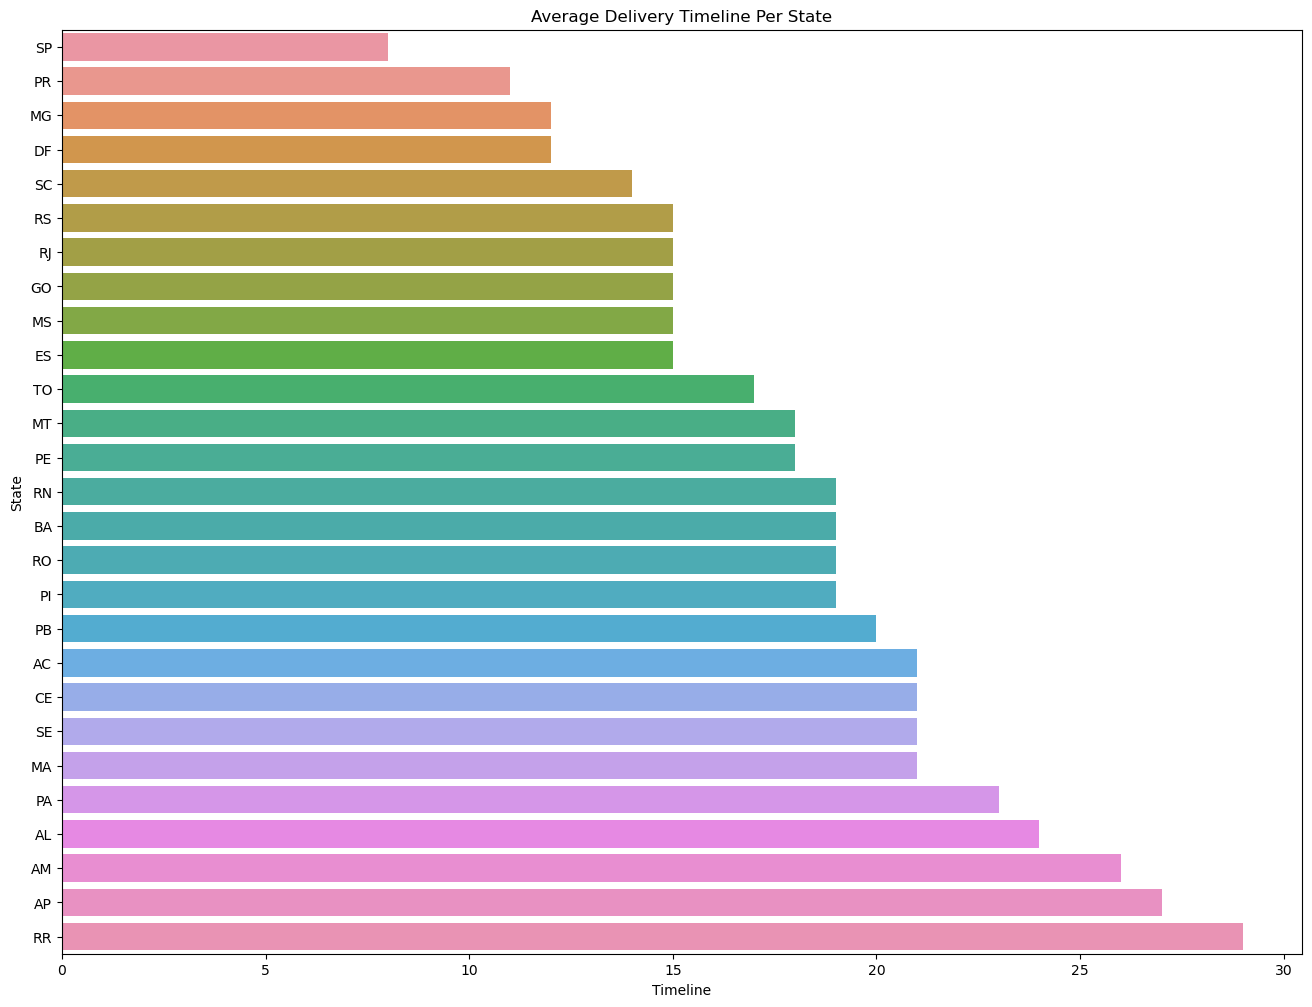

In [35]:
# visualize the data

plt.figure(figsize=(16, 12))
sns.barplot(data=quest13, x='timeline', y='customer_state')

plt.xlabel('Timeline')
plt.ylabel('State')
plt.title('Average Delivery Timeline Per State')

plt.show()

# Question 13: Accuracy (Estimated vs. Actual)

**Insights:** The average time for delivery across all states is 11 days. Also, the difference of the states' average accuracy was taken from the overall average accuracy. The states' whose differences is 5 and above should be investigated further.

In [36]:
# aggregate the data

quest14 = pd.read_sql('''
WITH state_accuracy AS (
    SELECT
        c.customer_state,
        AVG(order_estimated_delivery_date - order_delivered_customer_date) AS avg_accuracy
    FROM customers c
    JOIN orders o
        ON o.customer_id = c.customer_id
    WHERE o.order_delivered_customer_date IS NOT NULL
    GROUP BY c.customer_state
),
total_avg AS (
    SELECT
        AVG(order_estimated_delivery_date - order_delivered_customer_date) AS total_avg_accuracy
    FROM orders
    WHERE order_delivered_customer_date IS NOT NULL
)
SELECT
    sa.customer_state,
    sa.avg_accuracy,
    ta.total_avg_accuracy,
    sa.avg_accuracy - ta.total_avg_accuracy AS difference_from_total
FROM state_accuracy sa
CROSS JOIN total_avg ta
ORDER BY difference_from_total DESC;
''', engine)

In [37]:
quest14

,customer_state,avg_accuracy,total_avg_accuracy,difference_from_total
0,AC,20 days 01:50:53.400000,11 days 04:17:55.957616,8 days 21:32:57.442384
1,RO,19 days 09:31:25.802469,11 days 04:17:55.957616,8 days 05:13:29.844853
2,AP,19 days 01:25:34.119402,11 days 04:17:55.957616,7 days 21:07:38.161786
3,AM,18 days 20:26:36.986207,11 days 04:17:55.957616,7 days 16:08:41.028591
4,RR,16 days 14:16:13.243903,11 days 04:17:55.957616,5 days 09:58:17.286287
5,MT,13 days 16:27:11.497743,11 days 04:17:55.957616,2 days 12:09:15.540127
6,PA,13 days 09:16:15.324524,11 days 04:17:55.957616,2 days 04:58:19.366908
7,RS,13 days 05:00:13.427770,11 days 04:17:55.957616,2 days 00:42:17.470154
8,RN,12 days 23:05:46.959916,11 days 04:17:55.957616,1 days 18:47:51.002300
9,PR,12 days 14:52:20.189112,11 days 04:17:55.957616,1 days 10:34:24.231496


# Quetion 14: Average cost per delivery?

**Insights:** Sao Paulo leads with R$17.37 in average freight value

In [38]:
# aggregate the data

quest15 = pd.read_sql('''
WITH cte_freight AS (
    SELECT
    c.customer_state,
    o.order_id,
    SUM(oi.freight_value) AS total_value
    FROM customers c
    JOIN orders o
    ON o.customer_id = c.customer_id
    JOIN order_items oi
    ON oi.order_id = o.order_id
    GROUP BY c.customer_state, o.order_id
)
SELECT
ctf.customer_state,
AVG(ctf.total_value) AS avg_freight_value
FROM cte_freight ctf
GROUP BY ctf.customer_state
ORDER BY avg_freight_value
LIMIT 10;
''', engine)

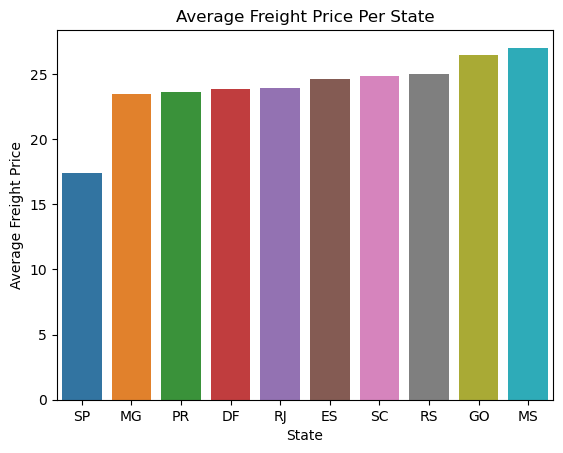

In [39]:
# visualize the data

sns.barplot(data=quest15, x='customer_state', y='avg_freight_value')

plt.xlabel('State')
plt.ylabel('Average Freight Price')
plt.title('Average Freight Price Per State')

plt.show()

## Key Summary

1. São Paulo dominates volume – SP has 41k customers (4× more than RJ) and generated R$1.04M in the last 3 months, making it the revenue powerhouse of the business.

2. High‑value states are small – PB, AP, and AC have the highest average order values (R$340–308), but they have little customer base which do not contribute largely to their revenue.

3. Revenue ≠ average spend – SP leads in total revenue because of sheer customer count, not because customers spend more. Its average order value is the lowest among all states (R$184).

4. Delivery and freight – SP has the fastest delivery (8.2 days) and lowest freight costs (R$17).

5. Peak revenue months differ by state – Most states peaked in November 2017 or mid‑2018, offering clear timing targets for regional campaigns.